
# To start
1. download the dataset: https://topbrain2025.grand-challenge.org/data/
2. store the dataset in your google drive folder  `CSE291G`, inside the folder you should have two folders
`labelsTr_topbrain_ct/topcow_ct_001_0000.nii.gz"`
and
`imagesTr_topbrain_ct/topcow_ct_001.nii.gz"`
3. then select GPU in google colab under `notebook setting`




#<font color="red">Data Exploration </font>

The following code is applied to 1 single patient CTA. But we can reuse this code later as python file to process all 24 patient in registration pipeline: **script.py**


DiffDRR: https://github.com/eigenvivek/DiffDRR
paper: https://arxiv.org/pdf/2208.12737


DiffPose:  https://github.com/eigenvivek/DiffPose


It does these steps:

1. Load the **CTA image** and **multiclass vessel label map**
2. Understand label IDs present in the case
3. Select hemisphere
4. Build controlled perturbations:
   - **Q1**: image noise after 2D projection
   - **Q2**: random vessel-volume loss
   - **Q3**: removal of proximal / medium / distal vessel groups
5. Generate a **projection-based pseudo-DSA** for debugging the pipeline
6. Save outputs for later registration experiments

## Files used

- `topcow_ct_001_0000.nii.gz` → CTA image volume
- `topcow_ct_001.nii.gz` → vessel label map


In [1]:

# Uncomment once if needed
# %pip install nibabel matplotlib scipy pandas


In [2]:
# Unmount Google Drive
from google.colab import drive
drive.flush_and_unmount()
print('Drive unmounted.')

Drive not mounted, so nothing to flush and unmount.
Drive unmounted.


In [3]:
# Re-mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive re-mounted.')

Mounted at /content/drive
Drive re-mounted.


In [4]:

from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter, rotate, shift, zoom
from scipy.optimize import minimize

In [5]:
label_path = Path('/content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct/')
input_path = Path('/content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct/')
output_path = Path('/content/drive/MyDrive/CSE291G/output/')
CT_PATH = input_path / 'topcow_ct_001_0000.nii'
LABEL_PATH = label_path / 'topcow_ct_001.nii'
OUT_DIR = output_path/'cse291_project_outputs_complete'
OUT_DIR.mkdir(exist_ok=True, parents=True)

print('CT_PATH   =', CT_PATH)
print('LABEL_PATH=', LABEL_PATH)
print('OUT_DIR   =', OUT_DIR)


CT_PATH   = /content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct/topcow_ct_001_0000.nii
LABEL_PATH= /content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct/topcow_ct_001.nii
OUT_DIR   = /content/drive/MyDrive/CSE291G/output/cse291_project_outputs_complete


## Load the image and label map

In [6]:
from google.colab import drive
# drive.mount('/content/drive', force_remount=True)
import nibabel as nib
import numpy as np

CT_PATH = "/content/drive/MyDrive/CSE291G/imagesTr_topbrain_ct/topcow_ct_001_0000.nii.gz"
LABEL_PATH = "/content/drive/MyDrive/CSE291G/labelsTr_topbrain_ct/topcow_ct_001.nii.gz"

# NifTi objects contain image data + metadata, metadata includes
# voxel spacing, coordinate system, orientation, scanner info
ct_img = nib.load(CT_PATH)
label_img = nib.load(LABEL_PATH)

# convert ct to numpy arrays
# eg. ct[x,y,z] = 285
ct = ct_img.get_fdata().astype(np.float32)
# labels[x,y,z]=12
# meaning: voxel belongs to vessel type 12
labels = label_img.get_fdata().astype(np.int16)

# convert voxel coordinates to physical coordinates
# eg. voxel (100,120,80) --> real world location (mm)
# might be useful for registration later

# Typical CT Affine Characteristics
# Diagonal elements: Usually [-voxel_size_x, voxel_size_y, voxel_size_z, 1] — the negative sign in X is common due to radiological coordinate conventions.
# Translation terms: Position of the first voxel in world space.
# No shear: Off-diagonal spatial terms are usually zero in CT.
affine = ct_img.affine
# e.g., voxel size in millimeters (0.5, 0.5, 0.6)
# means: x voxel = 0.5 mm, y voxel = 0.5 mm, z voxel = 0.6 mm

spacing = ct_img.header.get_zooms()[:3]
# how axes are oriented, ('R','A','S')
#X increases -> Left
#Y increases -> Back of head
#Z increases -> Upward
axcodes = nib.aff2axcodes(affine)

print("CT shape in (pixels, pixels, slices):", ct.shape)
print("Label shape:", labels.shape)
print("Voxel spacing:", spacing)
print("Axis codes:", axcodes)
print("CT min / max:", float(ct.min()), float(ct.max()))
print("Unique labels:", np.unique(labels))
print("Num unique labels:", len(np.unique(labels)))

assert ct.shape == labels.shape

CT shape in (pixels, pixels, slices): (284, 327, 243)
Label shape: (284, 327, 243)
Voxel spacing: (np.float32(0.507813), np.float32(0.507813), np.float32(0.625))
Axis codes: ('L', 'P', 'S')
CT min / max: -3024.0 3071.0
Unique labels: [ 0  1  2  3  4  5  8 11 12 13 14 17 18 21 22 23 24 25 26 27 29 30 33 35
 36 37 38 39 40]
Num unique labels: 29


- ct[x,y,z]
- x = left-right
- y = front-back
- z = slice index
- to get one slice: slice = ct[:,:,z]

*  the scan is anisotropic (Z resolution is slightly lower)


*  the scan covers roughly 14-16 cm of brain volume
*   the axis orientation is X axis -> left, Y axis -> posterior, Z axis-> superior

- what it means if X increases, then left shifts, Y increases, back of head, Z increases upward

- **In left right hemisphere occlusion to keep only the healthy hemisphere, we need to split along Axis = 0**



- CT intensity range: Hounsfield units (HU)
eg.
```
Air        ≈ -1000
Fat        ≈ -100
Water      = 0
Brain      ≈ 20–40
Bone       ≈ 1000+
Contrast   ≈ 200–500
```
In our dataset:
```
-3024 -> outside scan / padding
3071  -> very dense tissue
```

- Labels: 40 labels, 0 is background. More detailed info in the next cell


```
# This is formatted as code
```






## Label dictionary for TopBrain CTA

The dataset page says the TopBrain CTA labels include 40 classes, with labels 1–12 and 15 inherited from TopCoW.

<font color="purple"> **updated `TOPBRAIN_CTA_LABELS` since the previous one does not match the label order in `itksnap_labelmap_txt\labelmap_topbrain_ct.txt` provided in the dataset**</font>


In [7]:

# TOPBRAIN_CTA_LABELS = {
#     0: 'background',
#     1: 'BA',
#     2: 'R-P1P2',
#     3: 'L-P1P2',
#     4: 'R-ICA',
#     5: 'R-M1',
#     6: 'L-ICA',
#     7: 'L-M1',
#     8: 'R-Pcom',
#     9: 'L-Pcom',
#     10: 'Acom',
#     11: 'R-A1A2',
#     12: 'L-A1A2',
#     13: '3rd-A2',
#     14: 'R-A3',
#     15: 'L-A3',
#     # The exact TopBrain page contains additional distal / cerebellar / venous labels.
#     # For the project grouping below, we mainly need clinically meaningful proximal/medium/distal bins.
#     16: 'R-M2M3',
#     17: 'L-M2M3',
#     18: 'R-M4',
#     19: 'L-M4',
#     20: 'R-P3P4',
#     21: 'L-P3P4',
#     22: 'R-VA',
#     23: 'L-VA',
#     24: 'R-SCA',
#     25: 'L-SCA',
#     26: 'R-AICA',
#     27: 'L-AICA',
#     28: 'R-PICA',
#     29: 'L-PICA',
#     30: 'R-AChA',
#     31: 'L-AChA',
#     32: 'R-OA',
#     33: 'L-OA',
#     34: 'VoG',
#     35: 'StS',
#     36: 'R-TS',
#     37: 'L-TS',
#     38: 'R-SigS',
#     39: 'L-SigS',
#     40: 'SSS',
# }

TOPBRAIN_CTA_LABELS = {
    0: 'background',

    # Basilar / posterior circulation
    1: 'BA',
    2: 'R-P1P2',
    3: 'L-P1P2',

    # ICA + proximal MCA
    4: 'R-ICA',
    5: 'R-M1',
    6: 'L-ICA',
    7: 'L-M1',

    # communicating arteries
    8: 'R-Pcom',
    9: 'L-Pcom',
    10: 'Acom',

    # ACA
    11: 'R-A1A2',
    12: 'L-A1A2',
    13: 'R-A3',
    14: 'L-A3',
    15: '3rd-A2',
    16: '3rd-A3',

    # MCA distal
    17: 'R-M2',
    18: 'R-M3',
    19: 'L-M2',
    20: 'L-M3',

    # PCA distal
    21: 'R-P3P4',
    22: 'L-P3P4',

    # vertebral
    23: 'R-VA',
    24: 'L-VA',

    # cerebellar arteries
    25: 'R-SCA',
    26: 'L-SCA',
    27: 'R-AICA',
    28: 'L-AICA',
    29: 'R-PICA',
    30: 'L-PICA',

    # small branches
    31: 'R-AChA',
    32: 'L-AChA',
    33: 'R-OA',
    34: 'L-OA',

    # venous structures
    35: 'VoG',
    36: 'StS',
    37: 'ICVs',
    38: 'R-BVR',
    39: 'L-BVR',
    40: 'SSS'
}

unique_labels = np.unique(labels)
label_table = pd.DataFrame({
    'label_id': unique_labels,
    'name': [TOPBRAIN_CTA_LABELS.get(int(x), f'unknown_{int(x)}') for x in unique_labels],
    'voxel_count': [int((labels == x).sum()) for x in unique_labels],
}).sort_values('label_id').reset_index(drop=True)

assert label_table.voxel_count.sum() == np.prod(ct.shape)

label_table


,label_id,name,voxel_count
0,0,background,22487747
1,1,BA,2975
2,2,R-P1P2,1705
3,3,L-P1P2,1940
4,4,R-ICA,2444
5,5,R-M1,1075
6,8,R-Pcom,218
7,11,R-A1A2,1704
8,12,L-A1A2,1561
9,13,R-A3,769


## Quick visualization
- visualize one 2D slice from 3D volume and display it with matplot. Show both original CT and its vessel labels
- volume: 3D numpy array (CT or label map)
- axis: which direction to slice
- index: which slice number
- cmap: color map
- vmin, vmax: intensity range

axis meanings and anatomical direction
- axis 0: left <-> right
- axis 1: front <-> back
- axis 2: bottom <-> top

<font color="purple">(optional) the labels have their colors in the given dataset, we may consider to use them instead of `cmap` </font>

axis 2: axial slice, looking from above the head downward


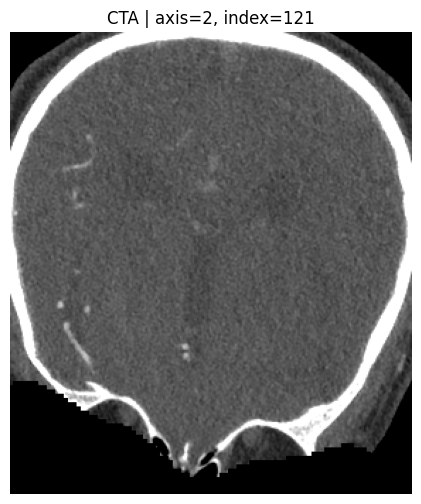

vessels label, each vessel ID gest a different color


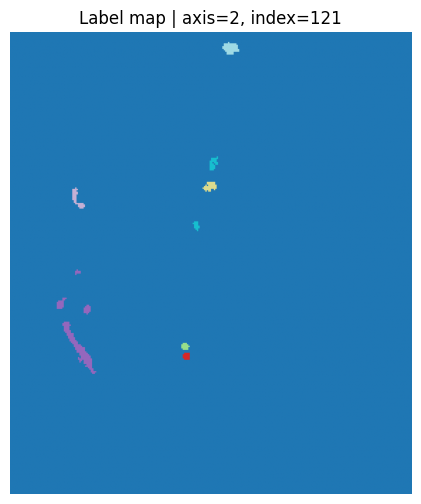

In [8]:

def show_slice(volume, axis=2, index=None, title='', cmap='gray', vmin=None, vmax=None):
    if index is None:
        index = volume.shape[axis] // 2
    if axis == 0:
        img = volume[index, :, :]
    elif axis == 1:
        img = volume[:, index, :]
    else:
        img = volume[:, :, index]
    plt.figure(figsize=(6, 6))
    plt.imshow(img.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax)
    plt.title(f'{title} | axis={axis}, index={index}')
    plt.axis('off')
    plt.show()


print("axis 2: axial slice, looking from above the head downward")
show_slice(ct, axis=2, title='CTA', vmin=-200, vmax=500)
print("vessels label, each vessel ID gest a different color")
show_slice(labels, axis=2, title='Label map', cmap='tab20')


axis 1: axial slice


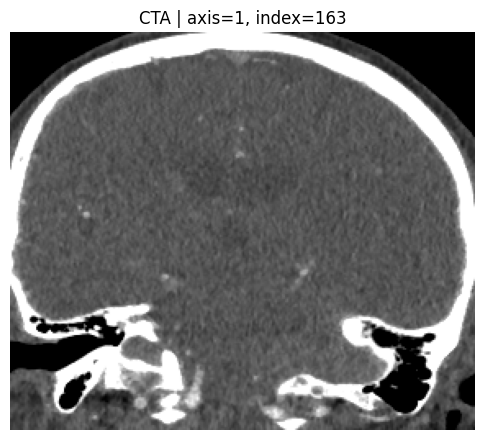

vessels label, each vessel ID gest a different color


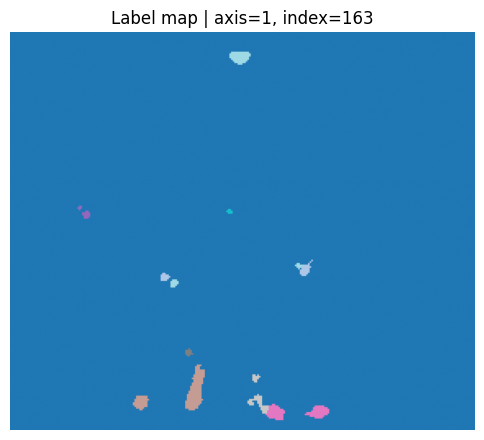

In [9]:
print("axis 1: axial slice")
show_slice(ct, axis=1, title='CTA', vmin=-200, vmax=500)
print("vessels label, each vessel ID gest a different color")
show_slice(labels, axis=1, title='Label map', cmap='tab20')

axis 1: axial slice


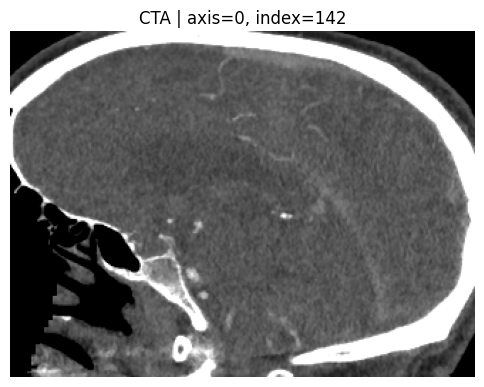

vessels label, each vessel ID gest a different color


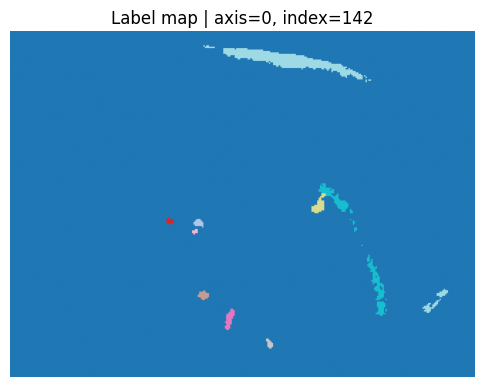

In [10]:
print("axis 1: axial slice")
show_slice(ct, axis=0, title='CTA', vmin=-200, vmax=500)
print("vessels label, each vessel ID gest a different color")
show_slice(labels, axis=0, title='Label map', cmap='tab20')


## Hemisphere selection that respects orientation

The Zenodo release says CTA images are stored in **LPS+ orientation**.
Still, instead of assuming the first half of axis 0 is always one side, we derive the **left-right axis** from the affine.


In [11]:

def get_left_right_axis_and_direction(affine):
    axcodes = nib.aff2axcodes(affine)
    # Find which axis corresponds to Left/Right.
    for axis, code in enumerate(axcodes):
        if code in ('L', 'R'):
            return axis, code
    raise ValueError(f'Could not find a left-right axis from affine. axcodes={axcodes}')


def keep_single_hemisphere(volume, affine, keep_side='right'):
    """
    Keep only one hemisphere using the affine-derived left-right axis.

    keep_side='right' means keep anatomical right, regardless of array storage direction.
    """
    lr_axis, positive_dir = get_left_right_axis_and_direction(affine)
    out = np.zeros_like(volume)
    n = volume.shape[lr_axis]
    mid = n // 2

    slicer_low = [slice(None)] * 3
    slicer_high = [slice(None)] * 3
    slicer_low[lr_axis] = slice(0, mid)
    slicer_high[lr_axis] = slice(mid, n)

    # If positive axis direction is 'L', then low indices are more 'R'.
    # If positive axis direction is 'R', then high indices are more 'R'.
    if keep_side.lower() == 'right':
        src = tuple(slicer_low) if positive_dir == 'L' else tuple(slicer_high)
    elif keep_side.lower() == 'left':
        src = tuple(slicer_high) if positive_dir == 'L' else tuple(slicer_low)
    else:
        raise ValueError("keep_side must be 'right' or 'left'")

    out[src] = volume[src]
    return out

lr_axis, lr_positive = get_left_right_axis_and_direction(affine)
print('Left-right axis:', lr_axis)
print('Positive direction along that axis:', lr_positive)


Left-right axis: 0
Positive direction along that axis: L


Remaining healthy-hemisphere vessel voxels: 42346


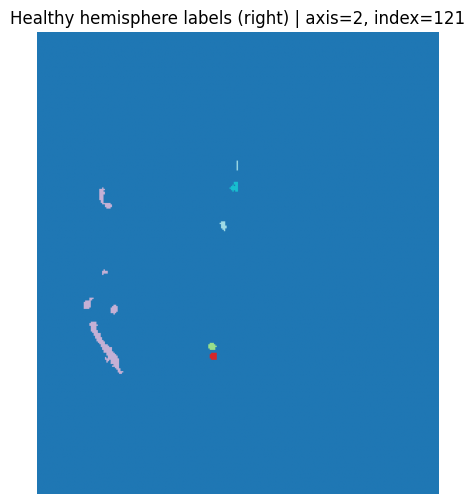

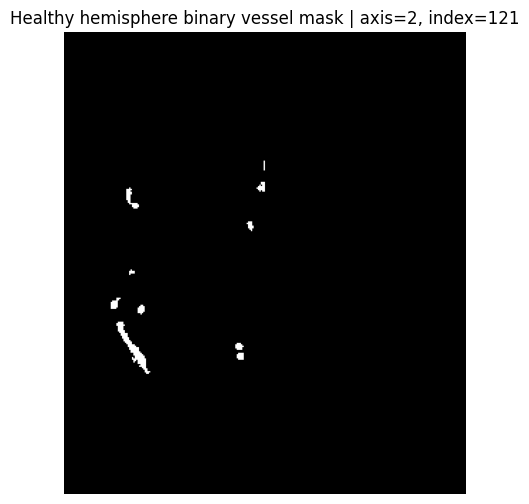

In [12]:

KEEP_SIDE = 'right'   # change to 'left' if needed

healthy_labels = keep_single_hemisphere(labels, affine, keep_side=KEEP_SIDE)
healthy_ct = keep_single_hemisphere(ct, affine, keep_side=KEEP_SIDE)
healthy_binary = (healthy_labels > 0).astype(np.uint8)

print('Remaining healthy-hemisphere vessel voxels:', int(healthy_binary.sum()))
show_slice(healthy_labels, axis=2, title=f'Healthy hemisphere labels ({KEEP_SIDE})', cmap='tab20')
show_slice(healthy_binary, axis=2, title='Healthy hemisphere binary vessel mask', cmap='gray')


Remaining healthy-hemisphere vessel voxels: 42346


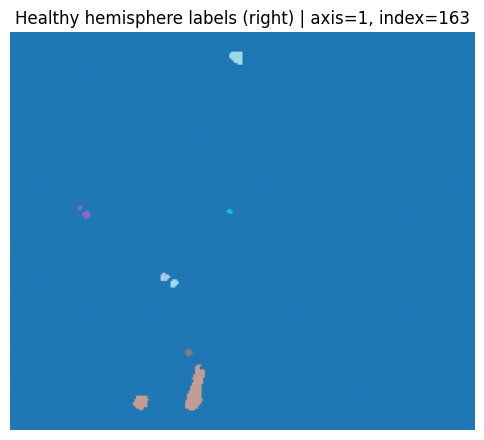

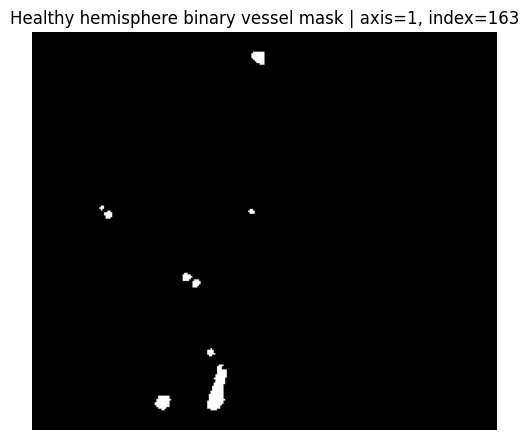

In [13]:
print('Remaining healthy-hemisphere vessel voxels:', int(healthy_binary.sum()))
show_slice(healthy_labels, axis=1, title=f'Healthy hemisphere labels ({KEEP_SIDE})', cmap='tab20')
show_slice(healthy_binary, axis=1, title='Healthy hemisphere binary vessel mask', cmap='gray')

## Helper functions

- save_nifti: This function saves a 3D volume as a .nii or .nii.gz medical image file.



In [14]:

def save_nifti(data, reference_img, out_path, dtype=None):
    arr = data.astype(dtype) if dtype is not None else data
    out_img = nib.Nifti1Image(arr, reference_img.affine, reference_img.header)
    nib.save(out_img, str(out_path))
    print('Saved:', out_path)



def save_png(image2d, out_path, cmap='gray'):
    plt.figure(figsize=(6, 6))
    plt.imshow(image2d, cmap=cmap)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight', pad_inches=0)
    plt.close()
    print('Saved:', out_path)


def normalize_01(x):
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)


# Pipeline Overview


```
1. CTA_original

2. CTA_original + apply transformation T = CTA_transformed

2. vessel perturbation on CTA_transformed: vessel removal (volume and types): CTA_transformed_pertubated

3. Render DSA on CTA_transformed_pertubated: DSA_observed

DSA_observed: DSA_original, DSA_removal_volume, DSA_removal_types, DSA_original_noise

4.
CTA_transformed
↓
CTA_moving

CTA_moving + DSA_observed and T
↓
DiffPose registration
↓
recover pose T
↓
compute mTRE

```



## Q2 — random vessel-volume loss

In [35]:

def remove_random_vessel_volume(binary_mask, removal_fraction, seed=0):
    """
    Randomly zero out a percentage of vessel voxels.
    removal_fraction in [0, 1].
    """
    if not (0.0 <= removal_fraction <= 1.0):
        raise ValueError('removal_fraction must be between 0 and 1')

    rng = np.random.default_rng(seed)
    out = binary_mask.copy()
    vessel_idx = np.argwhere(out > 0)
    n_remove = int(len(vessel_idx) * removal_fraction)

    if n_remove > 0:
        chosen = rng.choice(len(vessel_idx), size=n_remove, replace=False)
        voxels = vessel_idx[chosen]
        out[voxels[:, 0], voxels[:, 1], voxels[:, 2]] = 0
    return out

VOLUME_LOSS_LEVELS = [0.00, 0.10, 0.50, 0.95]
q2_masks = {frac: remove_random_vessel_volume(healthy_binary, frac, seed=42) for frac in VOLUME_LOSS_LEVELS}

for frac, mask in q2_masks.items():
    print(f'removal={frac:.0%} | remaining voxels={int(mask.sum())}')


removal=0% | remaining voxels=42346
removal=10% | remaining voxels=38112
removal=50% | remaining voxels=21173
removal=95% | remaining voxels=2118


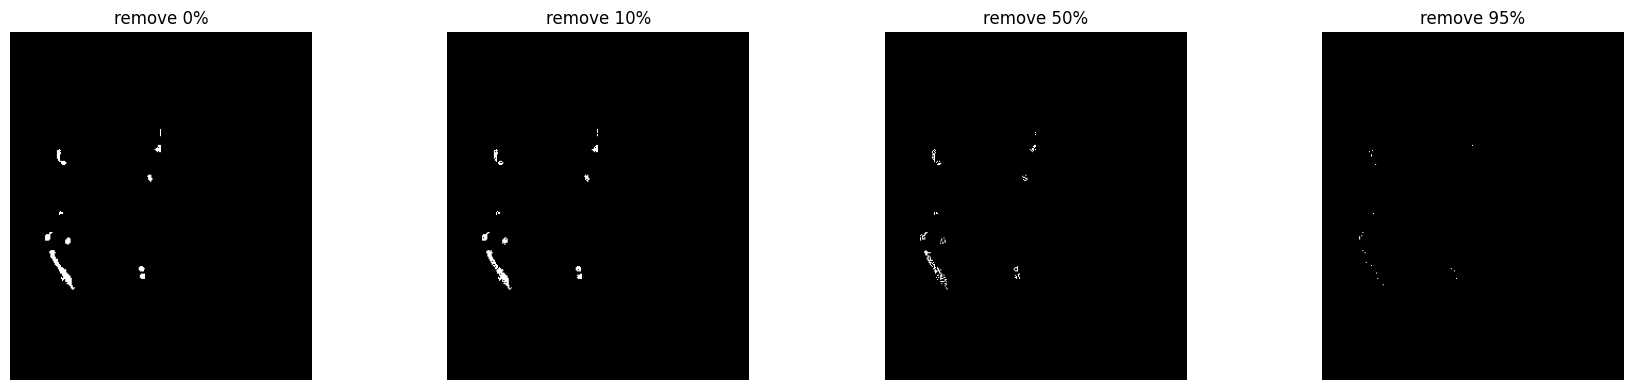

In [36]:

fig, axes = plt.subplots(1, len(VOLUME_LOSS_LEVELS), figsize=(18, 4))
for ax, frac in zip(axes, VOLUME_LOSS_LEVELS):
    img = q2_masks[frac][:, :, q2_masks[frac].shape[2] // 2].T
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(f'remove {frac:.0%}')
    ax.axis('off')
plt.tight_layout()
plt.show()



## Q3 — vessel-group removal

defines three groups:

- **proximal / large**: ICA, BA, VA
- **medium**: M1, A1/A2, P1/P2
- **distal**: M2/M3, A3, P3/P4, 3rd-A3

Below, the groups are written in terms of TopBrain CTA label IDs.
The code automatically ignores IDs that are not present in this specific case.


In [17]:

# VESSEL_GROUPS = {
#     'proximal': [1, 4, 6, 22, 23],      # BA, R/L ICA, R/L VA
#     'medium':   [2, 3, 5, 7, 11, 12],   # P1P2, M1, A1A2
#     'distal':   [13, 14, 15, 16, 17, 18, 20, 21],  # 3rd-A2, A3, M2M3/M4, P3P4
# }

#3rd-A2, 3rd-A3

VESSEL_GROUPS = {
    'proximal': [1, 4, 6, 23, 24],      # BA, R/L ICA, R/L VA
    'medium':   [2, 3, 5, 7, 11, 12],   # P1P2, M1, A1A2
    'distal':   [17, 19, 18, 20, 13, 14, 16],  # R/L M2, R/L-M3, R/L-A3, R/L-P3P4,3rd-A3
}


def get_present_group_ids(group_ids, label_map):
    present = set(np.unique(label_map).tolist())
    return [x for x in group_ids if x in present]


def remove_label_group(label_map, group_ids):
    out = label_map.copy()
    present_ids = get_present_group_ids(group_ids, label_map)
    out[np.isin(out, present_ids)] = 0
    return out, present_ids

q3_label_maps = {'baseline': healthy_labels.copy()}
q3_removed_present_ids = {'baseline': []}

for group_name, group_ids in VESSEL_GROUPS.items():
    new_map, present_ids = remove_label_group(healthy_labels, group_ids)
    q3_label_maps[group_name] = new_map
    q3_removed_present_ids[group_name] = present_ids

q3_binary_masks = {k: (v > 0).astype(np.uint8) for k, v in q3_label_maps.items()}

for name in q3_binary_masks:
    print(name, '| removed present IDs =', q3_removed_present_ids[name], '| remaining voxels =', int(q3_binary_masks[name].sum()))


baseline | removed present IDs = [] | remaining voxels = 42346
proximal | removed present IDs = [1, 4, 23, 24] | remaining voxels = 30088
medium | removed present IDs = [2, 3, 5, 11, 12] | remaining voxels = 36483
distal | removed present IDs = [17, 18, 13, 14] | remaining voxels = 30205


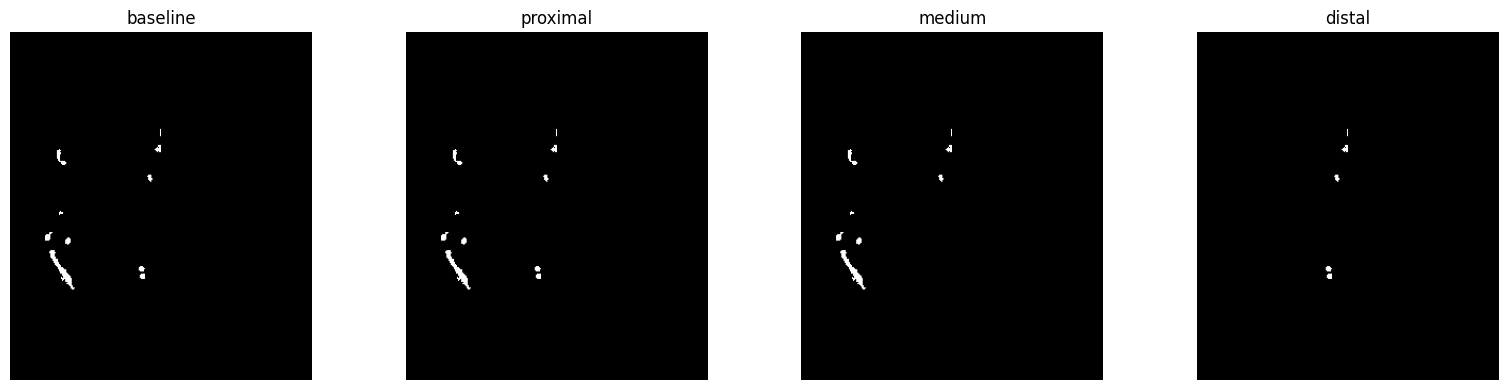

In [18]:

fig, axes = plt.subplots(1, len(q3_binary_masks), figsize=(4 * len(q3_binary_masks), 4))
if len(q3_binary_masks) == 1:
    axes = [axes]
for ax, (name, mask) in zip(axes, q3_binary_masks.items()):
    img = mask[:, :, mask.shape[2] // 2].T
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()


In [19]:

def add_gaussian_noise(image, sigma=0.03, seed=0):
    rng = np.random.default_rng(seed)
    noisy = image + rng.normal(0.0, sigma, size=image.shape)
    return np.clip(noisy, 0.0, 1.0)

def add_poisson_noise(image, peak=40, seed=0):
    rng = np.random.default_rng(seed)
    scaled = np.clip(image, 0.0, 1.0) * peak
    noisy = rng.poisson(scaled) / float(peak)
    return np.clip(noisy, 0.0, 1.0)



# Benchmark logic

For each scenario:

- the **observed DSA** is rendered from the scenario anatomy (baseline / Q2 / Q3) at the ground-truth pose `T_gt`
- the **moving model** used by registration remains the **original healthy model**
- pose optimization tries to recover `T_gt`

implement the transform as a **renderer pose** rather than physically storing `CTA_transform = T · CTA`.

In [20]:

def sample_random_rigid_params(seed=0,
                               tx_range_mm=(-5, 5),
                               ty_range_mm=(-5, 5),
                               tz_range_mm=(-5, 5),
                               rx_range_deg=(-5, 5),
                               ry_range_deg=(-5, 5),
                               rz_range_deg=(-5, 5)):
    rng = np.random.default_rng(seed)
    return np.array([
        float(rng.uniform(*rx_range_deg)),
        float(rng.uniform(*ry_range_deg)),
        float(rng.uniform(*rz_range_deg)),
        float(rng.uniform(*tx_range_mm)),
        float(rng.uniform(*ty_range_mm)),
        float(rng.uniform(*tz_range_mm)),
    ], dtype=np.float32)

T_gt = sample_random_rigid_params(seed=42)
print("T_gt [rx, ry, rz, tx, ty, tz] =", T_gt)

T_gt [rx, ry, rz, tx, ty, tz] = [ 2.7395606 -0.6112156  3.5859792  1.9736803 -4.0582266  4.7562237]


In [21]:

def maybe_downsample_volume(volume, factor):
    if factor == 1.0:
        return volume.astype(np.float32)
    return zoom(volume.astype(np.float32), zoom=(factor, factor, factor), order=0)


DOWNSAMPLE_FACTOR = 0.5  # speeds up registration rendering; set to 1.0 for full size
healthy_binary_ds = maybe_downsample_volume(healthy_binary, DOWNSAMPLE_FACTOR)
q2_masks_ds = {k: maybe_downsample_volume(v, DOWNSAMPLE_FACTOR) for k, v in q2_masks.items()}
q3_masks_ds = {k: maybe_downsample_volume(v, DOWNSAMPLE_FACTOR) for k, v in q3_binary_masks.items()}
spacing_ds = tuple(s / DOWNSAMPLE_FACTOR for s in spacing)

print("Downsampled healthy shape:", healthy_binary_ds.shape)
print("Downsampled spacing:", spacing_ds)

Downsampled healthy shape: (142, 164, 122)
Downsampled spacing: (np.float32(1.015626), np.float32(1.015626), np.float32(1.25))


## Apply ground truth projection T to the modified CTA

In [22]:

def apply_rigid_transform_volume(volume, rx_deg=0.0, ry_deg=0.0, rz_deg=0.0,
                                 tx_mm=0.0, ty_mm=0.0, tz_mm=0.0,
                                 spacing=(1.0, 1.0, 1.0), order=1):
    vol = volume.astype(np.float32)

    # Rotations around x, y, z using array axes conventions.
    if abs(rx_deg) > 1e-8:
        vol = rotate(vol, angle=rx_deg, axes=(1, 2), reshape=False, order=order, mode="constant", cval=0.0)
    if abs(ry_deg) > 1e-8:
        vol = rotate(vol, angle=ry_deg, axes=(0, 2), reshape=False, order=order, mode="constant", cval=0.0)
    if abs(rz_deg) > 1e-8:
        vol = rotate(vol, angle=rz_deg, axes=(0, 1), reshape=False, order=order, mode="constant", cval=0.0)

    # Convert mm translations into voxel shifts.
    shift_vox = (
        tx_mm / spacing[0],
        ty_mm / spacing[1],
        tz_mm / spacing[2],
    )
    if max(abs(s) for s in shift_vox) > 1e-8:
        vol = shift(vol, shift=shift_vox, order=order, mode="constant", cval=0.0)

    return vol




## Render DSA

For now we use a simple projection so the perturbation pipeline is correct and easy to debug

DiffDRR did not work well in our setting because it simulates realistic X-ray physics and expects a full CT attenuation volume containing tissue, bone, and contrast values. Our data, consists only of binary vessel masks where voxels are either vessel or background. Since vessels occupy only a small number of voxels along each X-ray path, the accumulated attenuation is extremely small, which results in very low image contrast and nearly blank projections.




In [23]:
def pseudo_dsa_from_volume_at_pose(binary_or_soft_volume, pose_params,
                                   proj_axis=0, blur_sigma=1.0, spacing=(1.0,1.0,1.0)):
    rx_deg, ry_deg, rz_deg, tx_mm, ty_mm, tz_mm = pose_params
    moved = apply_rigid_transform_volume(
        binary_or_soft_volume,
        rx_deg=rx_deg, ry_deg=ry_deg, rz_deg=rz_deg,
        tx_mm=tx_mm, ty_mm=ty_mm, tz_mm=tz_mm,
        spacing=spacing, order=1
    )
    moved = gaussian_filter(moved.astype(np.float32), sigma=blur_sigma)
    proj = moved.sum(axis=proj_axis)
    return normalize_01(proj)

## Create observed DSA images at the same ground-truth pose

This is the corrected benchmark construction:

- **baseline observed DSA** comes from the healthy anatomy at `T_gt`
- **Q2 observed DSA** comes from the volume-loss anatomy at `T_gt`
- **Q3 observed DSA** comes from the group-removed anatomy at `T_gt`
- **Q1** adds noise **after projection**

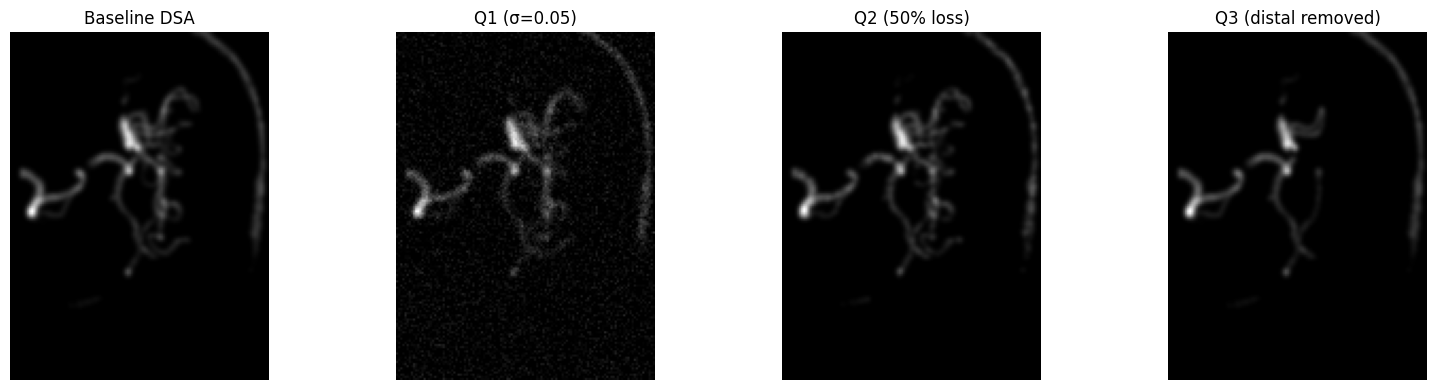

In [30]:

PROJ_AXIS = 0         # projection axis for pseudo-DSA

baseline_dsa_obs = pseudo_dsa_from_volume_at_pose(
    healthy_binary_ds, T_gt, proj_axis=PROJ_AXIS, blur_sigma=1.0, spacing=spacing_ds
)

GAUSSIAN_SIGMAS = [0.00, 0.01, 0.03, 0.05, 0.10]
POISSON_PEAKS = [20, 40, 80]

q1_gaussian_dsas = {sigma: add_gaussian_noise(baseline_dsa_obs, sigma=sigma, seed=42) for sigma in GAUSSIAN_SIGMAS}

q2_dsas_obs = {
    frac: pseudo_dsa_from_volume_at_pose(mask, T_gt, proj_axis=PROJ_AXIS, blur_sigma=1.0, spacing=spacing_ds)
    for frac, mask in q2_masks_ds.items()
}

q3_dsas_obs = {
    name: pseudo_dsa_from_volume_at_pose(mask, T_gt, proj_axis=PROJ_AXIS, blur_sigma=1.0, spacing=spacing_ds)
    for name, mask in q3_masks_ds.items()
}

plt.figure(figsize=(16, 4))

# 1. Baseline
plt.subplot(1, 4, 1)
plt.imshow(baseline_dsa_obs, cmap="gray")
plt.title("Baseline DSA")
plt.axis("off")

# 2. Q1 (Gaussian noise)
plt.subplot(1, 4, 2)
plt.imshow(q1_gaussian_dsas[0.05], cmap="gray")  # choose sigma
plt.title("Q1 (σ=0.05)")
plt.axis("off")

# 3. Q2
plt.subplot(1, 4, 3)
plt.imshow(q2_dsas_obs[0.50], cmap="gray")
plt.title("Q2 (50% loss)")
plt.axis("off")

# 4. Q3
plt.subplot(1, 4, 4)
plt.imshow(q3_dsas_obs["distal"], cmap="gray")
plt.title("Q3 (distal removed)")
plt.axis("off")

plt.tight_layout()
plt.show()

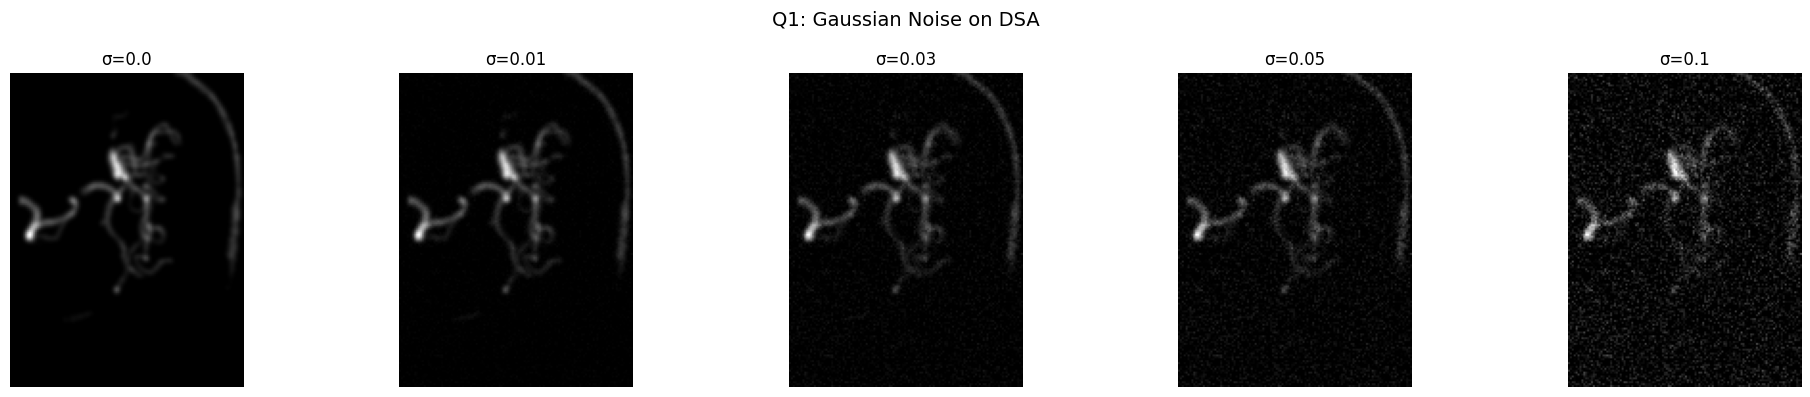

In [32]:
fig, axes = plt.subplots(1, len(q1_gaussian_dsas), figsize=(4 * len(q1_gaussian_dsas), 4))

if len(q1_gaussian_dsas) == 1:
    axes = [axes]

for ax, (sigma, img) in zip(axes, q1_gaussian_dsas.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"σ={sigma}")
    ax.axis("off")

plt.suptitle("Q1: Gaussian Noise on DSA", fontsize=14)
plt.tight_layout()
plt.show()

#<font color="red"> Registration with DiffPose-Style Optimization pipeline will be executed in script.py</font>